<a href="https://colab.research.google.com/github/riyaashukla30/AI-ML-Internship-Assignment-9/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification using CNN

## AI/ML Internship Assignment 9

Name: Riya Shukla  
Registration Number: 23BCE11293  
Application Number: IN26012655  
Batch Number: 2(B)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Filter cat (3) and dog (5)
cat, dog = 3, 5

train_filter = (y_train == cat) | (y_train == dog)
test_filter = (y_test == cat) | (y_test == dog)

X_train = X_train[train_filter.flatten()]
y_train = y_train[train_filter.flatten()]

X_test = X_test[test_filter.flatten()]
y_test = y_test[test_filter.flatten()]

# Convert labels → Cat=0, Dog=1
y_train = (y_train == dog).astype(int)
y_test = (y_test == dog).astype(int)

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2023s 12us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.5969 - loss: 0.6644 - val_accuracy: 0.6355 - val_loss: 0.6413
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.6768 - loss: 0.5982 - val_accuracy: 0.6940 - val_loss: 0.5845
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7134 - loss: 0.5540 - val_accuracy: 0.7280 - val_loss: 0.5315
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.7397 - loss: 0.5205 - val_accuracy: 0.7360 - val_loss: 0.5345
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7584 - loss: 0.4874 - val_accuracy: 0.7420 - val_loss: 0.5108
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7420 - loss: 0.5108
Accuracy: 0.7419999837875366


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


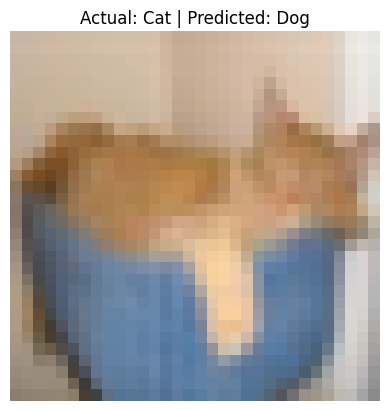

In [2]:
import random

# pick random image
index = random.randint(0, len(X_test)-1)

img = X_test[index]
true_label = y_test[index]

# prediction
pred = model.predict(img.reshape(1,32,32,3))
pred_label = 1 if pred > 0.5 else 0

# show image
plt.imshow(img)
plt.title(f"Actual: {'Dog' if true_label else 'Cat'} | Predicted: {'Dog' if pred_label else 'Cat'}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


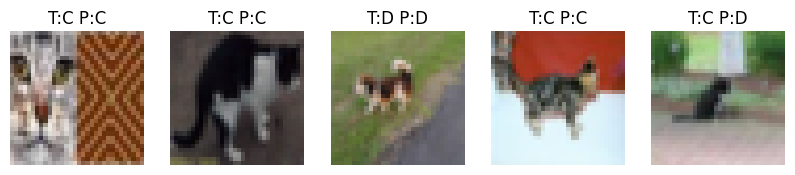

In [3]:
plt.figure(figsize=(10,5))

for i in range(5):
    index = random.randint(0, len(X_test)-1)
    img = X_test[index]
    true_label = y_test[index]

    pred = model.predict(img.reshape(1,32,32,3))
    pred_label = 1 if pred > 0.5 else 0

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"T:{'D' if true_label else 'C'} P:{'D' if pred_label else 'C'}")
    plt.axis("off")

plt.show()

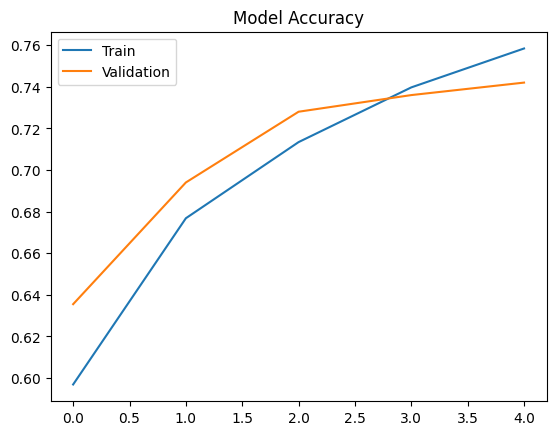

In [5]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Validation"])
plt.show()


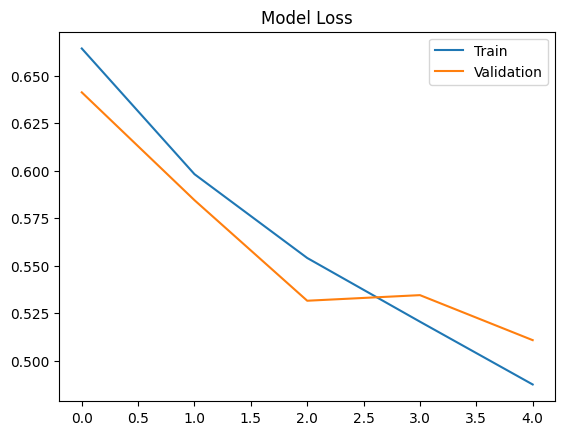

In [6]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train","Validation"])
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


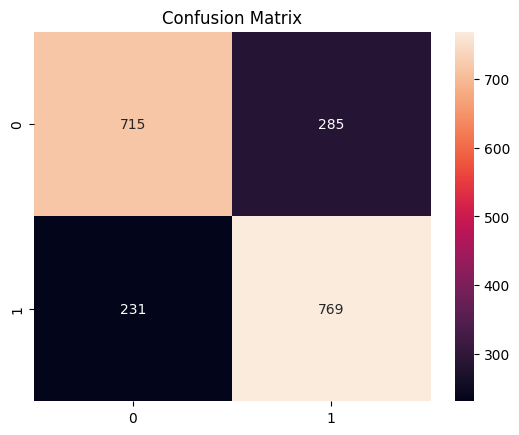

In [7]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [8]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.71      0.73      1000
           1       0.73      0.77      0.75      1000

    accuracy                           0.74      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.74      0.74      0.74      2000



## Objective

The objective of this project is to develop a Convolutional Neural Network (CNN) model to classify images into two categories: cats and dogs. The model is trained on a filtered version of the CIFAR-10 dataset, focusing only on relevant classes. The aim is to understand how CNNs extract important features from images such as edges, textures, and patterns, and use them for accurate classification. This project also helps in learning image preprocessing, model training, and performance evaluation techniques.

## Conclusion

In this project, a CNN model was successfully built and trained to classify images of cats and dogs. The model achieved good accuracy and showed consistent improvement during training, indicating effective learning of image features. The use of convolution and pooling layers helped in capturing spatial patterns from the images. Although the dataset used was limited and of low resolution, the model still performed reasonably well. The performance can be further enhanced by using larger datasets, applying data augmentation, or building deeper neural network architectures.